In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

data = pd.read_parquet('data/prepared_data.parquet')
print(data.shape)
print(f"Fraud procentas: {data['Is Fraud?'].mean()*100:.3f}%")

(2720821, 15)
Fraud procentas: 0.674%


In [ ]:
data['date'] = pd.to_datetime(data[['Year', 'Month', 'Day']])
data_sorted = data.sort_values('date').reset_index(drop=True)

split_i = int(len(data_sorted) * 0.85)
train_val_data = data_sorted.iloc[:split_i].copy()
test_data = data_sorted.iloc[split_i:].copy()

train_val_data.drop(columns=['date', 'Year', 'Month', 'Day'], inplace=True)
test_data.drop(columns=['date', 'Year', 'Month', 'Day'], inplace=True)

print(f"Train: {len(train_val_data)} eil | fraud: {train_val_data['Is Fraud?'].mean()*100:.3f}%")
print(f"Test:  {len(test_data)} eil | fraud: {test_data['Is Fraud?'].mean()*100:.3f}%")

Train: 2312697 eil | fraud: 0.788%
Test:  408124 eil | fraud: 0.031%


In [20]:
X_tv = train_val_data.drop(columns=['Is Fraud?'])
y_tv = train_val_data['Is Fraud?']

X_test = test_data.drop(columns=['Is Fraud?'])
y_test = test_data['Is Fraud?']

X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size=0.20,
    random_state=67,
    stratify=y_tv
)

print(f"Train: {len(X_train)} eil | fraud: {y_train.mean()*100:.3f}%")
print(f"Val: {len(X_val)} eil | fraud: {y_val.mean()*100:.3f}%")
print(f"Test: {len(X_test)} eil | fraud: {y_test.mean()*100:.3f}%")

Train: 1850157 eil | fraud: 0.788%
Val: 462540 eil | fraud: 0.788%
Test: 408124 eil | fraud: 0.031%


In [21]:
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve
)
import matplotlib.pyplot as plt

def get_predictions(model, X, threshold=0.5):
    y_proba = model.predict_proba(X)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)
    return y_proba, y_pred


def print_metrics(name, label, threshold, y, y_pred, y_proba):
    print("*************************************************************************")
    print(f"{name} | {label} | threshold={threshold:.3f}")
    print("*************************************************************************")
    print(classification_report(y, y_pred, target_names=['Ne-fraud', 'Fraud']))
    print(f"Precision: {precision_score(y, y_pred):.4f}")
    print(f"Recall: {recall_score(y, y_pred):.4f}")
    print(f"F1: {f1_score(y, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y, y_proba):.4f}")
    print(f"PR-AUC: {average_precision_score(y, y_proba):.4f}")
    print()
    print(f"Confusion matrix: {confusion_matrix(y, y_pred)}")


def plot_pr_curve(ax, y, y_pred, y_proba, threshold):
    prec, rec, _ = precision_recall_curve(y, y_proba)
    pr_auc = average_precision_score(y, y_proba)
    ax.plot(rec, prec, label=f'PR-AUC = {pr_auc:.4f}')
    ax.scatter(recall_score(y, y_pred), precision_score(y, y_pred),
               color='red', zorder=5, label=f'threshold={threshold:.3f}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall')
    ax.legend()
    ax.grid(True)


def plot_roc_curve(ax, y, y_proba):
    fpr, tpr, _ = roc_curve(y, y_proba)
    roc_auc = roc_auc_score(y, y_proba)
    ax.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.4f}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate (Recall)')
    ax.set_title('ROC Curve')
    ax.legend()
    ax.grid(True)


def plot_curves(name, label, y, y_pred, y_proba, threshold):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_pr_curve(axes[0], y, y_pred, y_proba, threshold)
    plot_roc_curve(axes[1], y, y_proba)
    plt.suptitle(f'{name} | {label}')
    plt.tight_layout()
    plt.show()


def full_evaluate(name, model, X, y, threshold = 0.5, label=''):
    y_proba, y_pred = get_predictions(model, X, threshold)
    print_metrics(name, label, threshold, y, y_pred, y_proba)
    plot_curves(name, label, y, y_pred, y_proba, threshold)
    results = {
        'precision': precision_score(y, y_pred),
        'recall': recall_score(y, y_pred),
        'f1': f1_score(y, y_pred),
        'roc_auc': roc_auc_score(y, y_proba),
        'pr_auc': average_precision_score(y, y_proba),
    }
    return results

def cv_score(model, X, y, cv=5, label=''):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=67)
    scores = cross_validate(
        model, X, y,
        cv=skf,
        scoring=['roc_auc', 'average_precision'],
        n_jobs=-1
    )
    print()
    print(f"CV-{cv} | {label}]")
    print(f"ROC-AUC: {scores['test_roc_auc'].mean():.4f}")
    print(f"std ROC-AUC: {scores['test_roc_auc'].std():.4f}")
    print(f"PR-AUC: {scores['test_average_precision'].mean():.4f}")
    print(f"std PR-AUC: {scores['test_average_precision'].std():.4f}")
    return scores

def balance_data(X, y, fraud_target_ratio):
    ratio = fraud_target_ratio / (1 - fraud_target_ratio)
    target_for_under = ratio / 2

    n_fraud = (y == 1).sum()
    n_majority_target = int(n_fraud / target_for_under)
    under_ratio = n_majority_target / (y == 0).sum()
    under_ratio = min(under_ratio, 1.0)

    print(f"=== Prieš balansavimą ===")
    print(f"  Fraud: {n_fraud}, Non-fraud: {(y==0).sum()}")
    print(f"  Fraud %: {y.mean()*100:.1f}%")
    print(f"  under_ratio: {under_ratio:.4f}, target_for_under: {target_for_under:.4f}, ratio: {ratio:.4f}")

    under = RandomUnderSampler(sampling_strategy={0: n_majority_target, 1: n_fraud}, random_state=67)
    X_u, y_u = under.fit_resample(X, y)

    print(f"\n=== Po undersampling ===")
    print(f"  Fraud: {(y_u==1).sum()}, Non-fraud: {(y_u==0).sum()}")
    print(f"  Fraud %: {y_u.mean()*100:.1f}%")

    over = SMOTE(sampling_strategy=ratio, random_state=67)
    X_bal, y_bal = over.fit_resample(X_u, y_u)

    print(f"\n=== Po SMOTE ===")
    print(f"  Fraud: {(y_bal==1).sum()}, Non-fraud: {(y_bal==0).sum()}")
    print(f"  Fraud %: {y_bal.mean()*100:.1f}%")

    return X_bal, y_bal



In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

## eks 1: nebalansuota

scale_pos_weight = 125.9

CV-5 | Nebalansuota + scale_pos_weight]
ROC-AUC: 0.9004
std ROC-AUC: 0.0032
PR-AUC: 0.1641
std PR-AUC: 0.0104
[0]	validation_0-aucpr:0.01810
[50]	validation_0-aucpr:0.10415
[100]	validation_0-aucpr:0.13289
[150]	validation_0-aucpr:0.14594
[200]	validation_0-aucpr:0.15487
[250]	validation_0-aucpr:0.16332
[299]	validation_0-aucpr:0.17045
*************************************************************************
XGB – Nebalansuota | Validacija | threshold=0.500
*************************************************************************
              precision    recall  f1-score   support

    Ne-fraud       1.00      0.80      0.89    458896
       Fraud       0.03      0.84      0.06      3644

    accuracy                           0.80    462540
   macro avg       0.52      0.82      0.48    462540
weighted avg       0.99      0.80      0.88    462540

Precision: 0.0328
Recall: 0.8364
F1: 0.0631
ROC-AUC: 0.9074
PR-AUC: 0.1705

Confusion matrix: [[369054  89842]


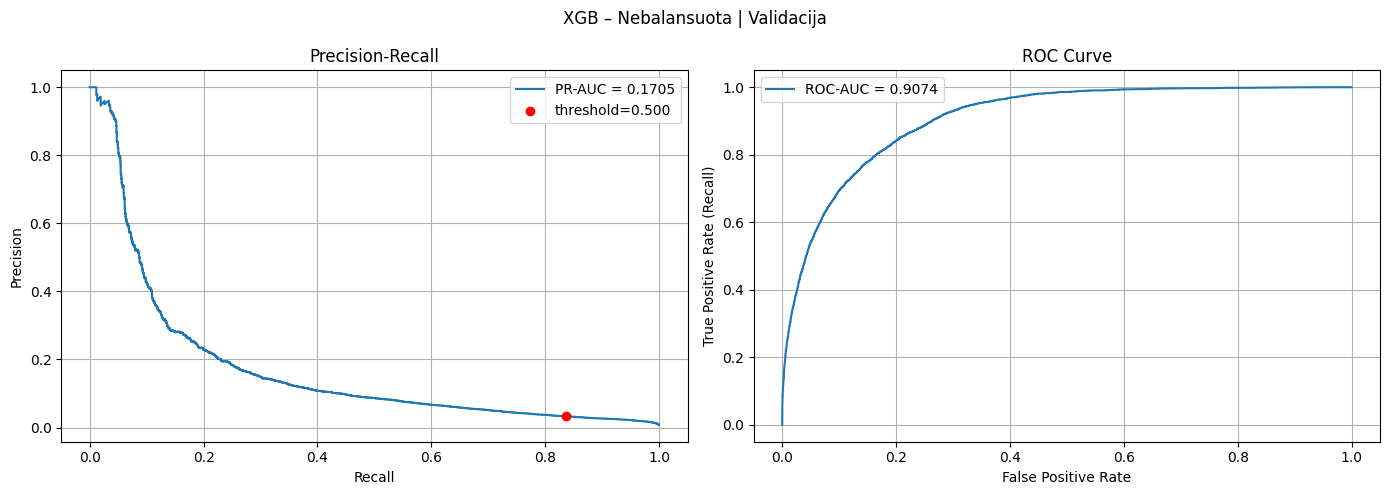

*************************************************************************
XGB – Nebalansuota | Testas | threshold=0.500
*************************************************************************
              precision    recall  f1-score   support

    Ne-fraud       1.00      0.89      0.94    407996
       Fraud       0.00      0.61      0.00       128

    accuracy                           0.89    408124
   macro avg       0.50      0.75      0.47    408124
weighted avg       1.00      0.89      0.94    408124

Precision: 0.0017
Recall: 0.6094
F1: 0.0034
ROC-AUC: 0.8781
PR-AUC: 0.1030

Confusion matrix: [[362848  45148]
 [    50     78]]


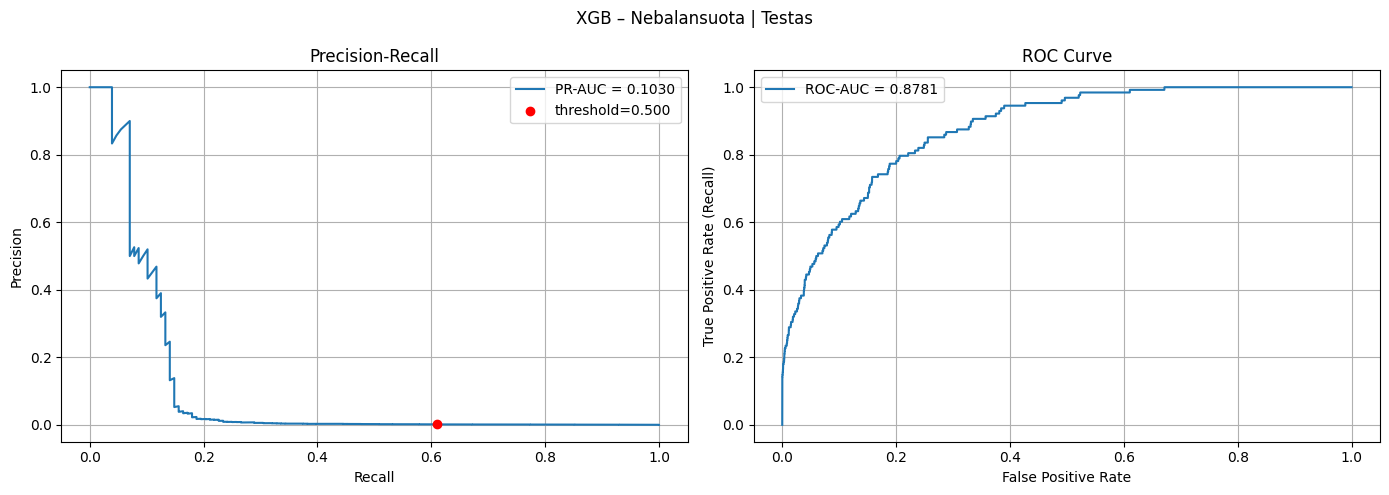

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.1f}")

xgb_no_bal = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=67,
    use_label_encoder=False,
    n_jobs=-1
)

cv_score(xgb_no_bal, X_train_scaled, y_train, cv=5, label='Nebalansuota')

xgb_no_bal.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=50
)

results_no_bal_val  = full_evaluate("XGB – Nebalansuota", xgb_no_bal, X_val_scaled,  y_val,  label='Validacija')
results_no_bal_test = full_evaluate("XGB – Nebalansuota", xgb_no_bal, X_test_scaled, y_test, label='Testas')

In [24]:
import numpy as np
import pandas as pd

y_proba_val, _ = get_predictions(xgb_no_bal, X_val_scaled)

results_no_bal = []

thresholds = np.arange(0.001, 0.55, 0.05)

for t in thresholds:
    y_pred = (y_proba_val >= t).astype(int)
    results_no_bal.append({
        'threshold': round(t, 3),
        'precision': precision_score(y_val, y_pred, zero_division=0),
        'recall': recall_score(y_val, y_pred, zero_division=0),
        'f1': f1_score(y_val, y_pred, zero_division=0),
        'pr_auc': average_precision_score(y_val, y_proba_val),
    })

df = pd.DataFrame(results_no_bal)
print(df.to_string(index=False))

print(df.nlargest(3, 'f1').to_string(index=False))

 threshold  precision   recall       f1   pr_auc
     0.001   0.007878 1.000000 0.015633 0.170522
     0.051   0.008859 0.999451 0.017562 0.170522
     0.101   0.011069 0.996981 0.021894 0.170522
     0.151   0.013865 0.990670 0.027348 0.170522
     0.201   0.016822 0.980790 0.033077 0.170522
     0.251   0.019541 0.964325 0.038306 0.170522
     0.301   0.022049 0.947585 0.043095 0.170522
     0.351   0.024524 0.924533 0.047780 0.170522
     0.401   0.026965 0.894347 0.052351 0.170522
     0.451   0.029710 0.865807 0.057448 0.170522
     0.501   0.032875 0.835895 0.063262 0.170522
 threshold  precision   recall       f1   pr_auc
     0.501   0.032875 0.835895 0.063262 0.170522
     0.451   0.029710 0.865807 0.057448 0.170522
     0.401   0.026965 0.894347 0.052351 0.170522


## eks 2: nebalansuota

=== Prieš balansavimą ===
  Fraud: 14577, Non-fraud: 1835580
  Fraud %: 0.8%
  under_ratio: 0.1429, target_for_under: 0.0556, ratio: 0.1111

=== Po undersampling ===
  Fraud: 14577, Non-fraud: 262386
  Fraud %: 5.3%

=== Po SMOTE ===
  Fraud: 29154, Non-fraud: 262386
  Fraud %: 10.0%

CV-5 | 10% fraud]
ROC-AUC: 0.9093
std ROC-AUC: 0.0017
PR-AUC: 0.6198
std PR-AUC: 0.0083
[0]	validation_0-aucpr:0.01578
[50]	validation_0-aucpr:0.12070
[100]	validation_0-aucpr:0.13199
[150]	validation_0-aucpr:0.14437
[200]	validation_0-aucpr:0.15457
[250]	validation_0-aucpr:0.16454
[299]	validation_0-aucpr:0.17231
*************************************************************************
XGB – 10% fraud | Validacija | threshold=0.500
*************************************************************************
              precision    recall  f1-score   support

    Ne-fraud       0.99      0.99      0.99    458896
       Fraud       0.23      0.21      0.22      3644

    accuracy                           

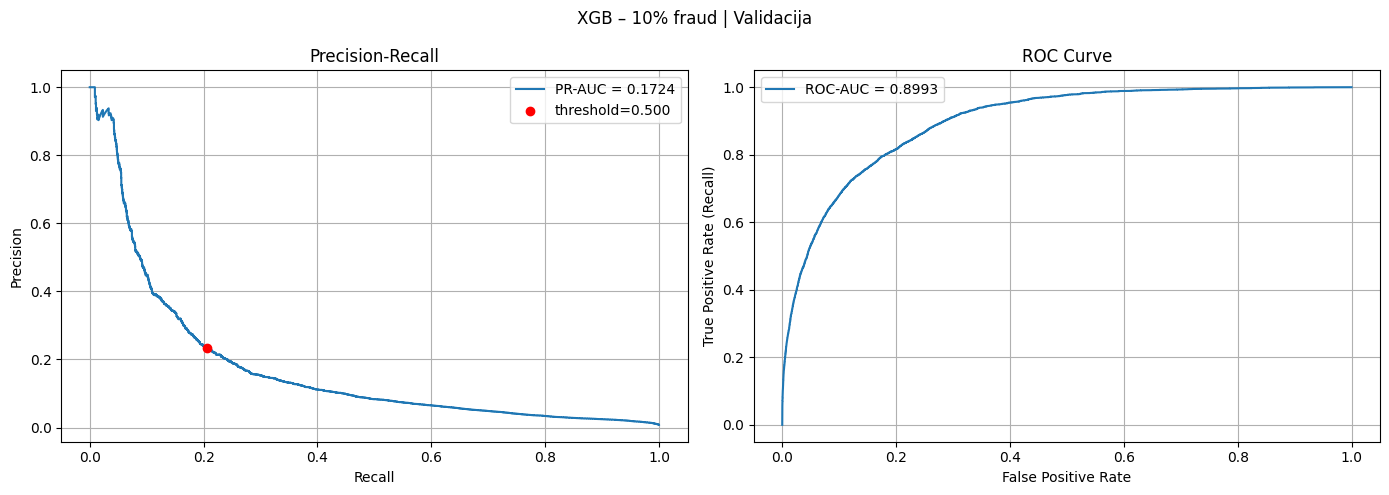

*************************************************************************
XGB – 10% fraud | Testas | threshold=0.500
*************************************************************************
              precision    recall  f1-score   support

    Ne-fraud       1.00      1.00      1.00    407996
       Fraud       0.03      0.20      0.05       128

    accuracy                           1.00    408124
   macro avg       0.51      0.60      0.52    408124
weighted avg       1.00      1.00      1.00    408124

Precision: 0.0286
Recall: 0.1953
F1: 0.0499
ROC-AUC: 0.8831
PR-AUC: 0.0952

Confusion matrix: [[407146    850]
 [   103     25]]


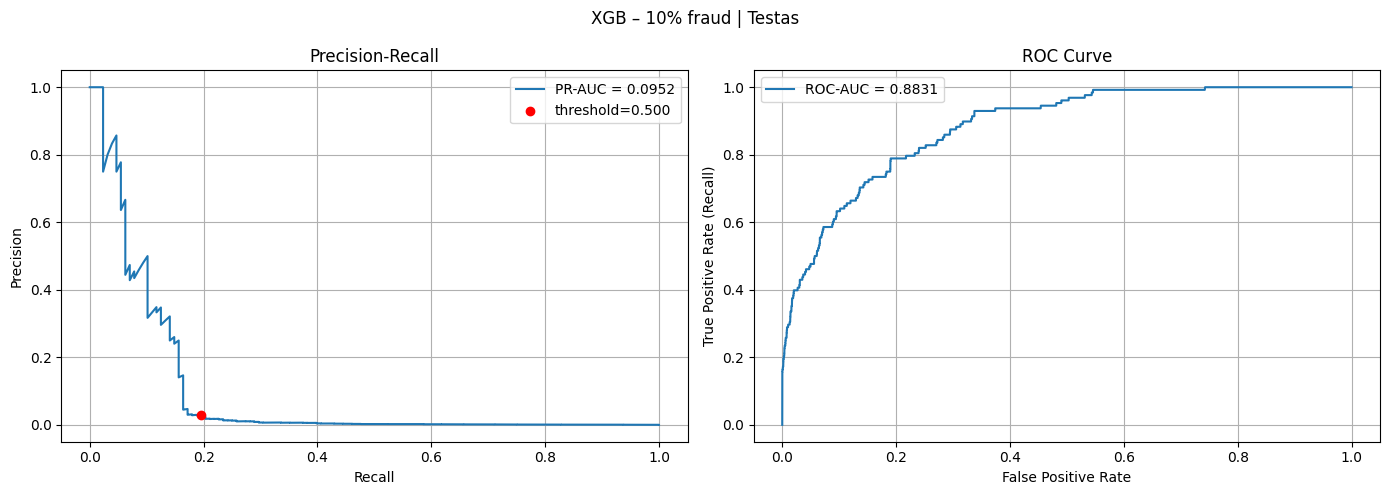

In [25]:
X_train_10, y_train_10 = balance_data(X_train_scaled, y_train, fraud_target_ratio=0.10)

xgb_10 = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    use_label_encoder=False,
    n_jobs=-1
)

cv_score(xgb_10, X_train_10, y_train_10, cv=5, label='10% fraud')

xgb_10.fit(
    X_train_10, y_train_10,
    eval_set=[(X_val_scaled, y_val)],
    verbose=50
)

results_10_val  = full_evaluate("XGB – 10% fraud", xgb_10, X_val_scaled,  y_val,  label='Validacija')
results_10_test = full_evaluate("XGB – 10% fraud", xgb_10, X_test_scaled, y_test, label='Testas')

In [26]:
import numpy as np
import pandas as pd

y_proba_val, _ = get_predictions(xgb_10, X_val_scaled)

results_10 = []

thresholds = np.arange(0.001, 0.55, 0.05)

for t in thresholds:
    y_pred = (y_proba_val >= t).astype(int)
    results_10.append({
        'threshold': round(t, 3),
        'precision': precision_score(y_val, y_pred, zero_division=0),
        'recall': recall_score(y_val, y_pred, zero_division=0),
        'f1': f1_score(y_val, y_pred, zero_division=0),
        'pr_auc': average_precision_score(y_val, y_proba_val),
    })

df = pd.DataFrame(results_10)
print(df.to_string(index=False))

print(df.nlargest(3, 'f1').to_string(index=False))

 threshold  precision   recall       f1   pr_auc
     0.001   0.007881 1.000000 0.015639 0.172388
     0.051   0.020708 0.940724 0.040525 0.172388
     0.101   0.029104 0.840285 0.056259 0.172388
     0.151   0.039437 0.757135 0.074970 0.172388
     0.201   0.055158 0.655873 0.101758 0.172388
     0.251   0.074705 0.543908 0.131367 0.172388
     0.301   0.099157 0.448683 0.162420 0.172388
     0.351   0.125198 0.368551 0.186904 0.172388
     0.401   0.152786 0.301043 0.202698 0.172388
     0.451   0.190267 0.250000 0.216082 0.172388
     0.501   0.234350 0.204446 0.218379 0.172388
 threshold  precision   recall       f1   pr_auc
     0.501   0.234350 0.204446 0.218379 0.172388
     0.451   0.190267 0.250000 0.216082 0.172388
     0.401   0.152786 0.301043 0.202698 0.172388


## eks 3: nebalansuota

=== Prieš balansavimą ===
  Fraud: 14577, Non-fraud: 1835580
  Fraud %: 0.8%
  under_ratio: 0.0322, target_for_under: 0.2463, ratio: 0.4925

=== Po undersampling ===
  Fraud: 14577, Non-fraud: 59191
  Fraud %: 19.8%

=== Po SMOTE ===
  Fraud: 29153, Non-fraud: 59191
  Fraud %: 33.0%

CV-5 | 33% fraud]
ROC-AUC: 0.9086
std ROC-AUC: 0.0022
PR-AUC: 0.8315
std PR-AUC: 0.0046
[0]	validation_0-aucpr:0.01667
[50]	validation_0-aucpr:0.11136
[100]	validation_0-aucpr:0.12485
[150]	validation_0-aucpr:0.13456
[200]	validation_0-aucpr:0.14371
[250]	validation_0-aucpr:0.15432
[299]	validation_0-aucpr:0.16172
*************************************************************************
XGB – 33% fraud | Validacija | threshold=0.500
*************************************************************************
              precision    recall  f1-score   support

    Ne-fraud       1.00      0.90      0.95    458896
       Fraud       0.05      0.68      0.09      3644

    accuracy                           0

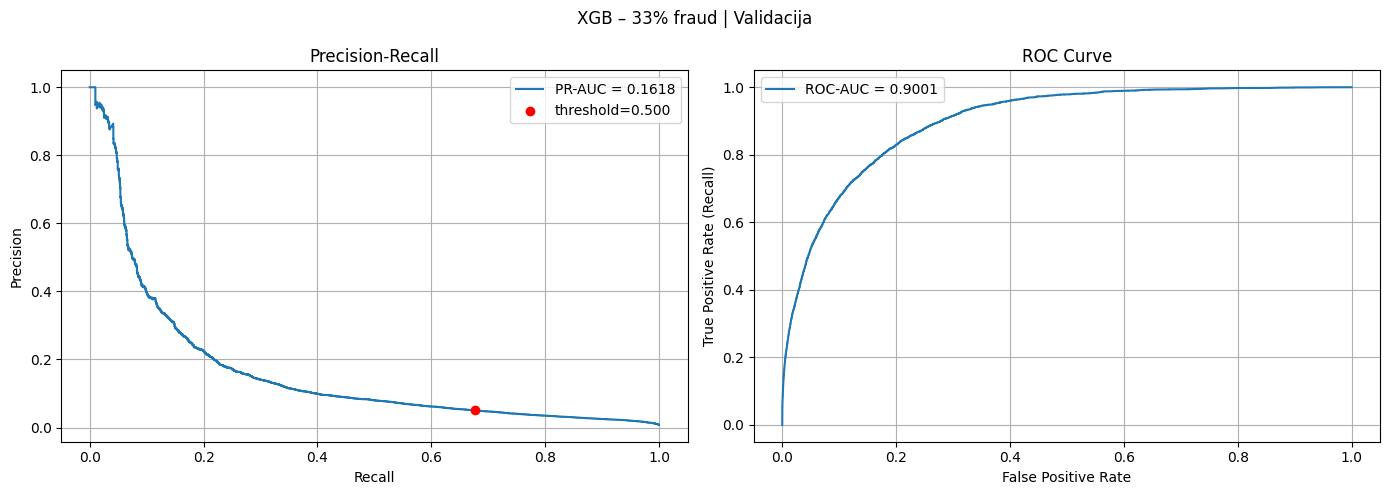

*************************************************************************
XGB – 33% fraud | Testas | threshold=0.500
*************************************************************************
              precision    recall  f1-score   support

    Ne-fraud       1.00      0.96      0.98    407996
       Fraud       0.00      0.45      0.01       128

    accuracy                           0.96    408124
   macro avg       0.50      0.71      0.49    408124
weighted avg       1.00      0.96      0.98    408124

Precision: 0.0036
Recall: 0.4531
F1: 0.0071
ROC-AUC: 0.8771
PR-AUC: 0.0946

Confusion matrix: [[391917  16079]
 [    70     58]]


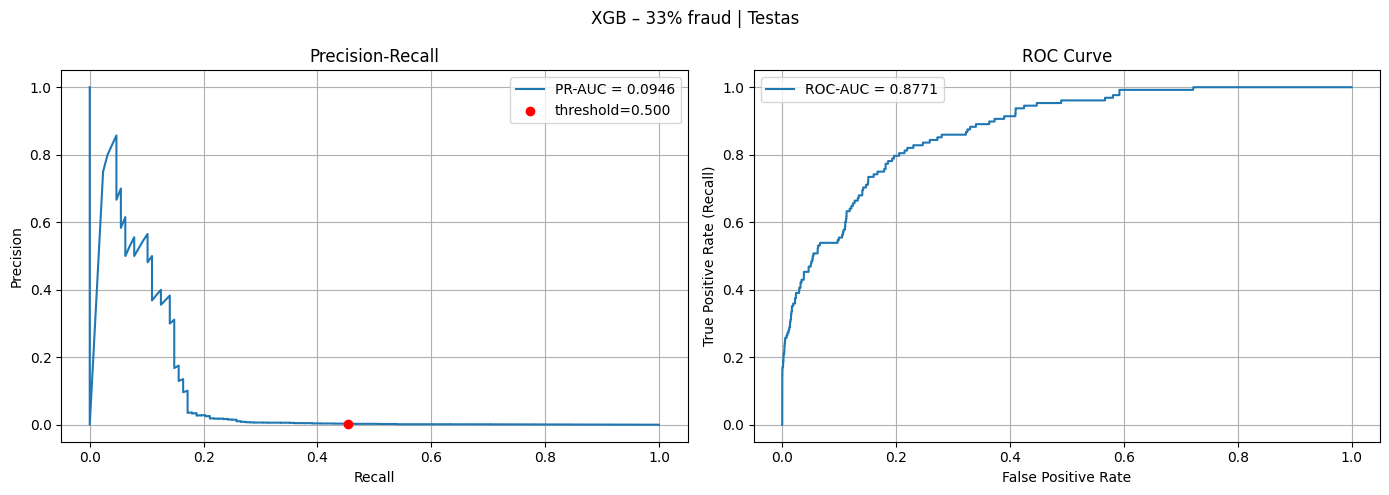

In [27]:
X_train_33, y_train_33 = balance_data(X_train_scaled, y_train, fraud_target_ratio=0.33)

xgb_33 = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    use_label_encoder=False,
    n_jobs=-1
)

cv_score(xgb_33, X_train_33, y_train_33, cv=5, label='33% fraud')

xgb_33.fit(
    X_train_33, y_train_33,
    eval_set=[(X_val_scaled, y_val)],
    verbose=50
)

results_33_val  = full_evaluate("XGB – 33% fraud", xgb_33, X_val_scaled,  y_val,  label='Validacija')
results_33_test = full_evaluate("XGB – 33% fraud", xgb_33, X_test_scaled, y_test, label='Testas')

In [28]:
import numpy as np
import pandas as pd

y_proba_val, _ = get_predictions(xgb_33, X_val_scaled)

results_33 = []

thresholds = np.arange(0.001, 0.55, 0.05)

for t in thresholds:
    y_pred = (y_proba_val >= t).astype(int)
    results_33.append({
        'threshold': round(t, 3),
        'precision': precision_score(y_val, y_pred, zero_division=0),
        'recall': recall_score(y_val, y_pred, zero_division=0),
        'f1': f1_score(y_val, y_pred, zero_division=0),
        'pr_auc': average_precision_score(y_val, y_proba_val),
    })

df = pd.DataFrame(results_33)
print(df.to_string(index=False))

print(df.nlargest(3, 'f1').to_string(index=False))

 threshold  precision   recall       f1   pr_auc
     0.001   0.007878 1.000000 0.015633 0.161802
     0.051   0.009852 0.997530 0.019512 0.161802
     0.101   0.014147 0.982711 0.027892 0.161802
     0.151   0.018703 0.959934 0.036691 0.161802
     0.201   0.022400 0.932217 0.043749 0.161802
     0.251   0.025421 0.895445 0.049438 0.161802
     0.301   0.028592 0.862239 0.055349 0.161802
     0.351   0.032212 0.823820 0.062000 0.161802
     0.401   0.036620 0.783205 0.069969 0.161802
     0.451   0.042403 0.732437 0.080165 0.161802
     0.501   0.050701 0.675357 0.094322 0.161802
 threshold  precision   recall       f1   pr_auc
     0.501   0.050701 0.675357 0.094322 0.161802
     0.451   0.042403 0.732437 0.080165 0.161802
     0.401   0.036620 0.783205 0.069969 0.161802


---
## 6. XGBoost parametrai


| Parametras | Default | Ką daro |
|---|---|---|
| `n_estimators` | 100 | Kiek medžių |
| `max_depth` | 6 | Medžio gylis |
| `learning_rate` | 0.3 | Žingsnis |
| `subsample` | 1.0 | Kiek % eilučių naudojama kiekvienam medžiui |
| `colsample_bytree` | 1.0 | Kiek % požymių naudojama kiekvienam medžiui |
| `min_child_weight` | 1 | Min. svorių suma lape |
| `gamma` | 0 | Min. loss sumažėjimas splitui |
| `reg_alpha` | 0 | L1 regularizacija |
| `reg_lambda` | 1 | L2 regularizacija |

In [29]:
X_train_best = X_train_10
y_train_best = y_train_10

param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.7, 0.8, 1.0],
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=67)

base_xgb = xgb.XGBClassifier(
    n_estimators=200,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=67,
    use_label_encoder=False,
    n_jobs=-1
)

grid = GridSearchCV(
    base_xgb,
    param_grid,
    cv=skf,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_best, y_train_best)

print("Geriausi parametrai:", grid.best_params_)
print(f"Geriausia CV PR-AUC: {grid.best_score_:.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits

Geriausi parametrai: {'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 1, 'subsample': 0.8}
Geriausia CV PR-AUC: 0.7496


*************************************************************************
XGB – GridSearch | Validacija | threshold=0.500
*************************************************************************
              precision    recall  f1-score   support

    Ne-fraud       0.99      0.99      0.99    458896
       Fraud       0.26      0.31      0.28      3644

    accuracy                           0.99    462540
   macro avg       0.63      0.65      0.64    462540
weighted avg       0.99      0.99      0.99    462540

Precision: 0.2622
Recall: 0.3060
F1: 0.2824
ROC-AUC: 0.9308
PR-AUC: 0.2379

Confusion matrix: [[455758   3138]
 [  2529   1115]]


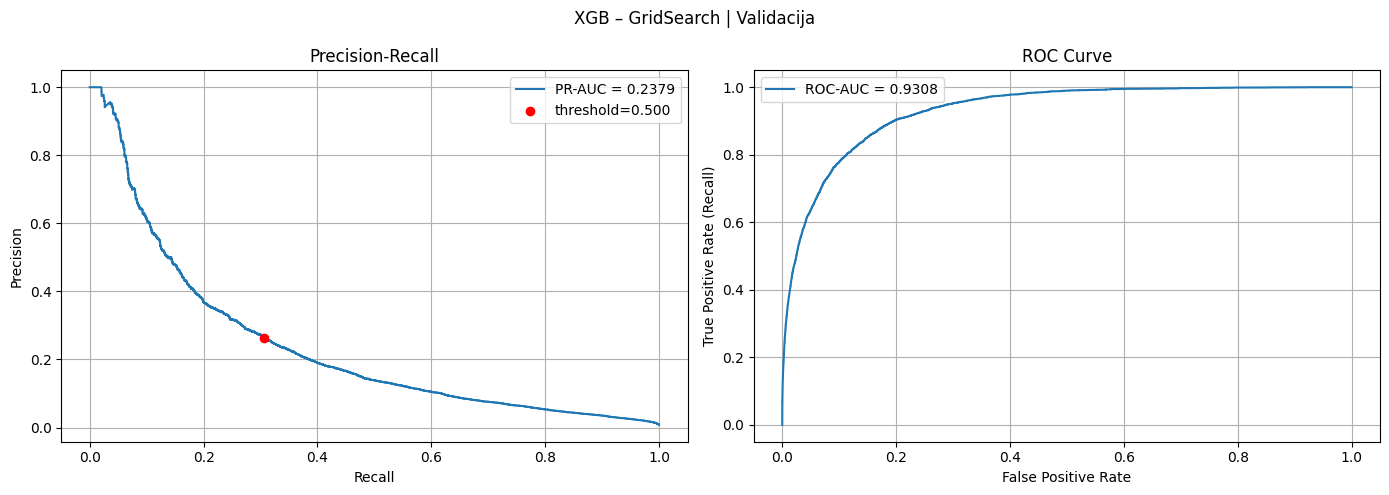

*************************************************************************
XGB – GridSearch | Testas | threshold=0.500
*************************************************************************
              precision    recall  f1-score   support

    Ne-fraud       1.00      1.00      1.00    407996
       Fraud       0.04      0.20      0.07       128

    accuracy                           1.00    408124
   macro avg       0.52      0.60      0.54    408124
weighted avg       1.00      1.00      1.00    408124

Precision: 0.0433
Recall: 0.1953
F1: 0.0708
ROC-AUC: 0.8996
PR-AUC: 0.0978

Confusion matrix: [[407443    553]
 [   103     25]]


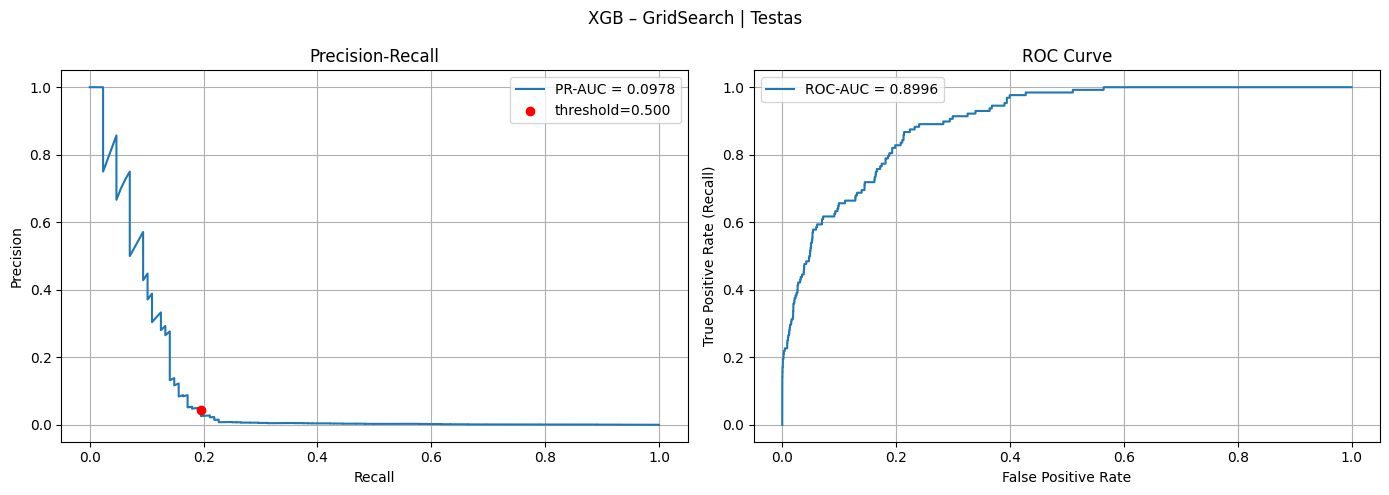

In [30]:
best_xgb = grid.best_estimator_

results_grid_val  = full_evaluate("XGB – GridSearch", best_xgb, X_val_scaled,  y_val,  label='Validacija')
results_grid_test = full_evaluate("XGB – GridSearch", best_xgb, X_test_scaled, y_test, label='Testas')

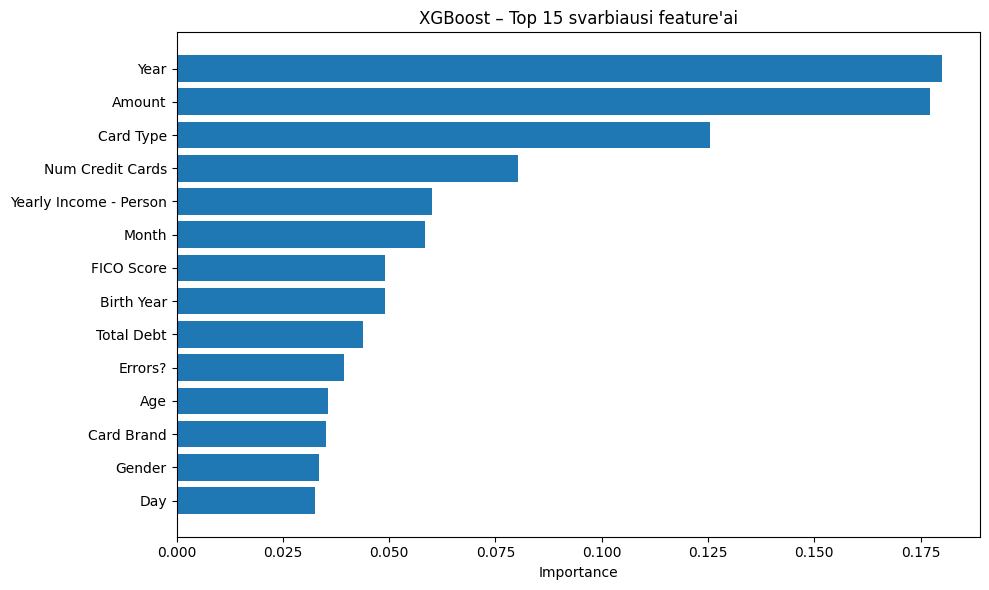

               feature  importance
                  Year    0.179970
                Amount    0.177320
             Card Type    0.125364
      Num Credit Cards    0.080293
Yearly Income - Person    0.060143
                 Month    0.058535
            FICO Score    0.049120
            Birth Year    0.049036
            Total Debt    0.043910
               Errors?    0.039484
                   Age    0.035522
            Card Brand    0.035215
                Gender    0.033474
                   Day    0.032612


In [10]:
import matplotlib.pyplot as plt

feature_names = X_train.columns.tolist()
importances = best_xgb.feature_importances_

fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(fi_df['feature'][:15][::-1], fi_df['importance'][:15][::-1])
plt.title('XGBoost – Top 15 svarbiausi feature\'ai')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(fi_df.to_string(index=False))

In [ ]:
import joblib
import os
os.makedirs('models', exist_ok=True)

joblib.dump(best_xgb, 'models/xgb_best.pkl')
joblib.dump(scaler, 'models/scaler.pkl')


✓ Modelis išsaugotas
